In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = (
    ROOT
    / "data"
    / "processed"
    / "fiverr_gigs_cleaned.csv"
)

MODEL_PATH = (
    ROOT
    / "models"
    / "best_demand_model.joblib"
)

MODELS_PATH = ROOT / "models"
REPORTS_PATH = ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"

In [2]:
df = pd.read_csv(
    DATA_PATH
)

demand_model = joblib.load(
    MODEL_PATH
)

print(df.shape)

(1259, 15)


In [3]:
cluster_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=1500,
)

X_text = cluster_vectorizer.fit_transform(
    df["title_clean"]
)

print("Ukuran matriks TF-IDF:", X_text.shape)

Ukuran matriks TF-IDF: (1259, 1301)


,k,silhouette_score
0,4,0.056326
1,5,0.061178
2,6,0.060158
3,7,0.055474
4,8,0.057736
5,9,0.062285
6,10,0.054199
7,11,0.058750
8,12,0.070515


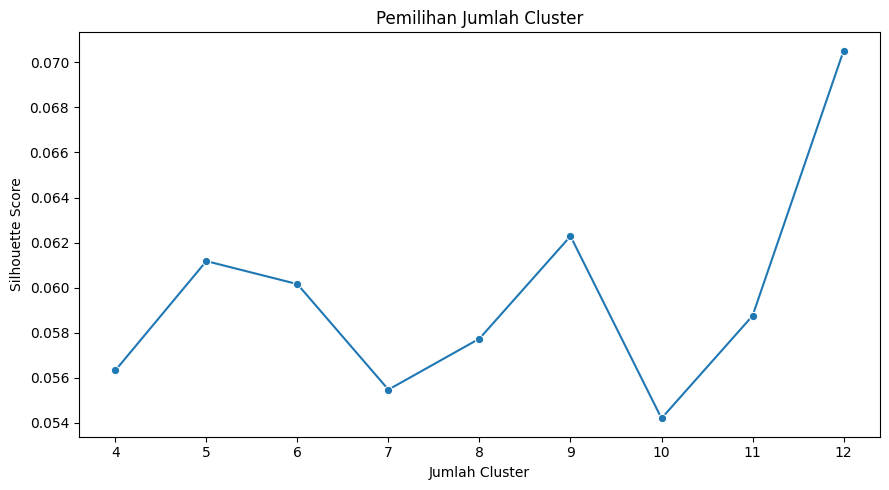

In [4]:
cluster_evaluation = []

for k in range(4, 13):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(
        X_text
    )

    score = silhouette_score(
        X_text,
        labels,
        metric="cosine",
    )

    cluster_evaluation.append(
        {
            "k": k,
            "silhouette_score": score,
        }
    )

cluster_scores = pd.DataFrame(
    cluster_evaluation
)

display(cluster_scores)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=cluster_scores,
    x="k",
    y="silhouette_score",
    marker="o",
)

plt.title("Pemilihan Jumlah Cluster")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "11_cluster_selection.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [5]:
best_k = int(
    cluster_scores.loc[
        cluster_scores[
            "silhouette_score"
        ].idxmax(),
        "k",
    ]
)

print("Jumlah cluster terbaik:", best_k)

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20,
)

df["cluster"] = kmeans_model.fit_predict(
    X_text
)

Jumlah cluster terbaik: 12


In [6]:
terms = (
    cluster_vectorizer
    .get_feature_names_out()
)

centroid_order = (
    kmeans_model
    .cluster_centers_
    .argsort(axis=1)[:, ::-1]
)

cluster_top_terms = {}

for cluster_id in range(best_k):
    top_terms = [
        terms[index]
        for index in centroid_order[
            cluster_id,
            :8,
        ]
    ]

    cluster_top_terms[
        cluster_id
    ] = top_terms

    print(
        f"Cluster {cluster_id}:",
        ", ".join(top_terms),
    )

Cluster 0: google, sheets, google sheets, excel google, excel, sheet, script, apps script
Cluster 1: data, help, provide, tasks, design, scrape, sql, python
Cluster 2: data science, science, data, machine, machine learning, learning, science machine, python
Cluster 3: scraping, web, web scraping, scraping data, data mining, mining, data, extraction
Cluster 4: python, analysis, using, data, data analysis, using python, script, python script
Cluster 5: engineering, data engineering, data, visualization, data cleaning, cleaning, engineering pipeline, wrangling
Cluster 6: learning, machine, machine learning, deep, deep learning, python, projects, learning python
Cluster 7: develop, develop data, data, pipelines, etl pipelines, develop etl, ssis, etl
Cluster 8: etl, data, create, pipeline, pipelines, etl pipeline, azure, using
Cluster 9: big data, big, data, spark, hadoop, pyspark, hive, data analysis
Cluster 10: excel, vba, macros, formulas, excel vba, spreadsheet, excel spreadsheet, formu

In [7]:
for cluster_id in range(best_k):
    print(
        "\n",
        "=" * 70,
    )

    print(
        f"CLUSTER {cluster_id}"
    )

    print(
        "Top terms:",
        cluster_top_terms[
            cluster_id
        ],
    )

    examples = (
        df[
            df["cluster"] == cluster_id
        ]["gig_title"]
        .head(10)
        .tolist()
    )

    for title in examples:
        print("-", title)

automatic_niche_names = {
    cluster_id: " / ".join(
        cluster_top_terms[
            cluster_id
        ][:3]
    )
    for cluster_id in range(
        best_k
    )
}

df["niche_name"] = (
    df["cluster"]
    .map(automatic_niche_names)
)


CLUSTER 0
Top terms: ['google', 'sheets', 'google sheets', 'excel google', 'excel', 'sheet', 'script', 'apps script']
- I will automate your workspace with google apps script
- I will create professional excel and google sheets
- I will automate excel, CSV, or google sheets data tasks using python scripting
- I will create excel and google sheets macros, vba, apps script, api
- I will be your perfect google sheets wizard
- I will solve your excel or google sheets problem
- I will be expert in excel, microsoft excel, google sheets, vba, formula, charts etc
- I will be your google sheets formula, script, and automation expert
- I will automate google sheet and excel formulas, macros, vba, apps script, api
- I will simplify and streamline google sheets with apps script

CLUSTER 1
Top terms: ['data', 'help', 'provide', 'tasks', 'design', 'scrape', 'sql', 'python']
- I will do automation and build bots in python and selenium
- I will automate your social media searches
- I will code an ind

In [8]:
prediction_features = [
    "title_clean",
    "price_pkr",
    "seller_level",
    "title_word_count",
]

prediction_log = demand_model.predict(
    df[prediction_features]
)

df["predicted_review"] = np.clip(
    np.expm1(prediction_log),
    0,
    None,
)

In [9]:
market_gap_summary = (
    df.groupby(
        [
            "cluster",
            "niche_name",
        ]
    )
    .agg(
        competition_count=(
            "gig_title",
            "count",
        ),
        predicted_demand_median=(
            "predicted_review",
            "median",
        ),
        predicted_demand_mean=(
            "predicted_review",
            "mean",
        ),
        observed_review_median=(
            "review_count",
            "median",
        ),
        rated_gig_count=(
            "review_count",
            "count",
        ),
        median_price_pkr=(
            "price_pkr",
            "median",
        ),
    )
    .reset_index()
)

display(market_gap_summary)

,cluster,niche_name,competition_count,predicted_demand_median,predicted_demand_mean,observed_review_median,rated_gig_count,median_price_pkr
0,0,google / sheets / google sheets,41,32.133369,88.177396,61.0,32,6526.0
1,1,data / help / provide,480,4.439498,9.188753,9.0,172,4351.0
2,2,data science / science / data,74,12.480473,17.924691,15.0,57,6526.0
3,3,scraping / web / web scraping,97,47.464909,89.025944,68.0,73,3263.0
4,4,python / analysis / using,105,8.044389,16.309466,18.0,53,5438.0
5,5,engineering / data engineering / data,81,1.969290,2.959042,1.5,28,5438.0
6,6,learning / machine / machine learning,113,14.079998,23.432015,20.0,95,10876.0
7,7,develop / develop data / data,32,2.307481,3.713322,2.0,13,10332.0
8,8,etl / data / create,102,2.240035,2.897570,2.0,31,4351.0
9,9,big data / big / data,39,3.440484,5.286022,4.0,19,4351.0


In [10]:
demand_scaler = MinMaxScaler()
competition_scaler = MinMaxScaler()

market_gap_summary[
    "demand_score"
] = demand_scaler.fit_transform(
    market_gap_summary[
        ["predicted_demand_median"]
    ]
).ravel()

market_gap_summary[
    "competition_score"
] = competition_scaler.fit_transform(
    market_gap_summary[
        ["competition_count"]
    ]
).ravel()

market_gap_summary[
    "low_competition_score"
] = (
    1
    - market_gap_summary[
        "competition_score"
    ]
)

market_gap_summary[
    "market_gap_score"
] = 100 * (
    0.65
    * market_gap_summary[
        "demand_score"
    ]
    +
    0.35
    * market_gap_summary[
        "low_competition_score"
    ]
)

market_gap_summary = (
    market_gap_summary
    .sort_values(
        "market_gap_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

market_gap_summary[
    "market_gap_rank"
] = (
    np.arange(
        1,
        len(market_gap_summary) + 1,
    )
)

display(market_gap_summary)

,cluster,niche_name,competition_count,predicted_demand_median,predicted_demand_mean,observed_review_median,rated_gig_count,median_price_pkr,demand_score,competition_score,low_competition_score,market_gap_score,market_gap_rank
0,10,excel / vba / macros,77,77.524428,108.478474,146.5,52,3263.0,1.000000,0.127706,8.722944e-01,95.530303,1
1,3,scraping / web / web scraping,97,47.464909,89.025944,68.0,73,3263.0,0.602151,0.170996,8.290043e-01,68.154981,2
2,0,google / sheets / google sheets,41,32.133369,88.177396,61.0,32,6526.0,0.399233,0.049784,9.502165e-01,59.207699,3
3,2,data science / science / data,74,12.480473,17.924691,15.0,57,6526.0,0.139119,0.121212,8.787879e-01,39.800335,4
4,6,learning / machine / machine learning,113,14.079998,23.432015,20.0,95,10876.0,0.160290,0.205628,7.943723e-01,38.221859,5
5,11,engineer / data engineer / data,18,2.243415,2.760654,2.5,4,5982.0,0.003628,0.000000,1.000000e+00,35.235829,6
6,9,big data / big / data,39,3.440484,5.286022,4.0,19,4351.0,0.019472,0.045455,9.545455e-01,34.674757,7
7,7,develop / develop data / data,32,2.307481,3.713322,2.0,13,10332.0,0.004476,0.030303,9.696970e-01,34.230340,8
8,4,python / analysis / using,105,8.044389,16.309466,18.0,53,5438.0,0.080406,0.188312,8.116883e-01,33.635491,9
9,5,engineering / data engineering / data,81,1.969290,2.959042,1.5,28,5438.0,0.000000,0.136364,8.636364e-01,30.227273,10


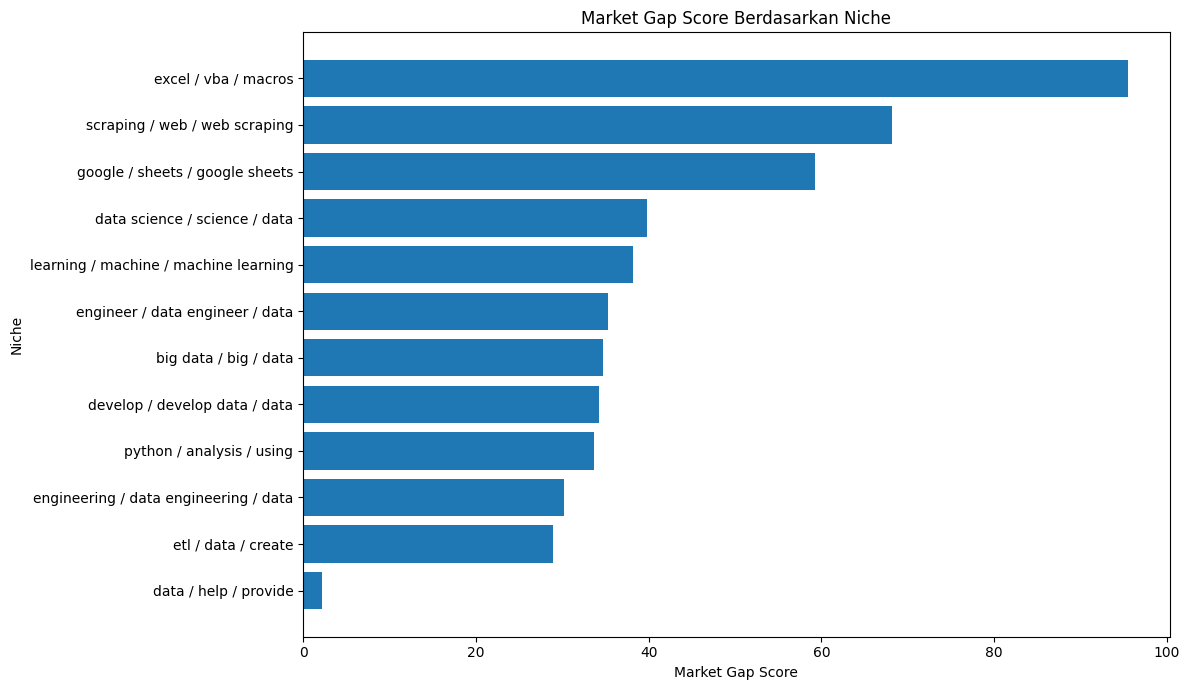

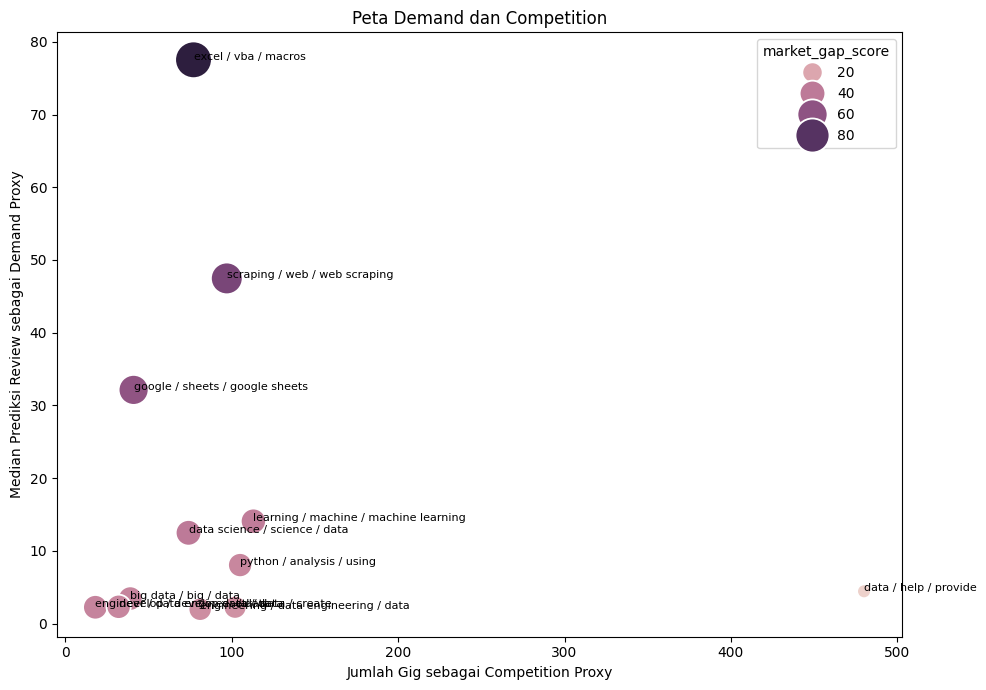

In [12]:
plt.figure(figsize=(12, 7))

plot_gap = (
    market_gap_summary
    .sort_values(
        "market_gap_score"
    )
)

plt.barh(
    plot_gap["niche_name"],
    plot_gap["market_gap_score"],
)

plt.title("Market Gap Score Berdasarkan Niche")
plt.xlabel("Market Gap Score")
plt.ylabel("Niche")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "12_market_gap_ranking.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=market_gap_summary,
    x="competition_count",
    y="predicted_demand_median",
    size="market_gap_score",
    hue="market_gap_score",
    sizes=(100, 700),
)

for _, row in market_gap_summary.iterrows():
    plt.annotate(
        row["niche_name"],
        (
            row["competition_count"],
            row[
                "predicted_demand_median"
            ],
        ),
        fontsize=8,
    )

plt.title("Peta Demand dan Competition")
plt.xlabel("Jumlah Gig sebagai Competition Proxy")
plt.ylabel("Median Prediksi Review sebagai Demand Proxy")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "13_demand_competition_map.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [14]:
CLUSTERED_DATA_PATH = (
    ROOT
    / "data"
    / "processed"
    / "fiverr_gigs_with_clusters.csv"
)

MARKET_GAP_PATH = (
    ROOT
    / "data"
    / "processed"
    / "market_gap_summary.csv"
)

df.to_csv(
    CLUSTERED_DATA_PATH,
    index=False,
)

market_gap_summary.to_csv(
    MARKET_GAP_PATH,
    index=False,
)

joblib.dump(
    cluster_vectorizer,
    MODELS_PATH
    / "cluster_vectorizer.joblib",
)

joblib.dump(
    kmeans_model,
    MODELS_PATH
    / "kmeans_model.joblib",
)

print("Semua hasil market gap disimpan.")

Semua hasil market gap disimpan.
